In [69]:
#!pip install numpy pandas matplotlib seaborn imbalanced-learn scikit-plot scikit-learn
import os
for dirname, _, filenames in os.walk('/kaggle/input/'):
   for filename in filenames:
       print(os.path.join(dirname, filename))

/kaggle/input/healthcare-dataset-stroke-data.csv


In [70]:
import os
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.gridspec as grid_spec
import seaborn as sns
from imblearn.over_sampling import SMOTE
import scikitplot as skplt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn.tree import DecisionTreeRegressor,DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score, precision_score, f1_score
import warnings
warnings.filterwarnings('ignore')


In [71]:
df = pd.read_csv('/kaggle/input/healthcare-dataset-stroke-data.csv')
df.head(20)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1
7,10434,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1
9,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1


### A concise summary of a DataFrame is provided

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


# Exploring the data

We have now dealt with the missing values in the data.

Next, I want to **explore** the data.

Does age makes one more likely to suffer a stroke? What about gender? Or BMI?

These are all questions that can be explored and answered with some data visulization. 

First, let's look at the numeric/continuous variable distribtion

In [73]:
variables = [variable for variable in df.columns if variable not in ['id','stroke']]

conts = ['age','avg_glucose_level','bmi']

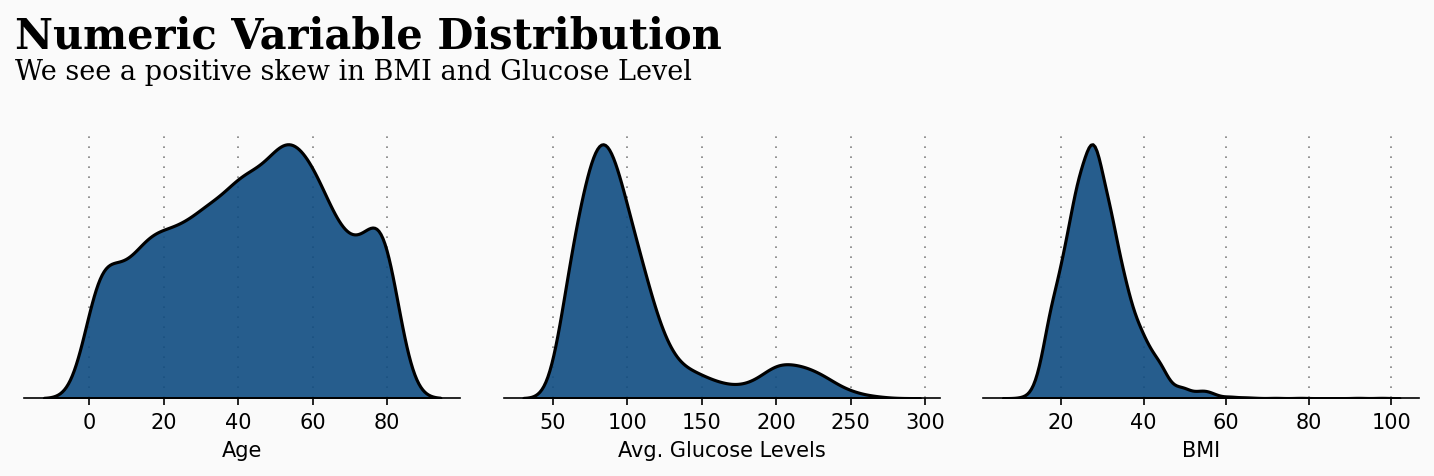

In [74]:
fig = plt.figure(figsize=(12, 12), dpi=150, facecolor='#fafafa')
gs = fig.add_gridspec(4, 3)
gs.update(wspace=0.1, hspace=0.4)

background_color = "#fafafa"

plot = 0
for row in range(0, 1):
    for col in range(0, 3):
        locals()["ax"+str(plot)] = fig.add_subplot(gs[row, col])
        locals()["ax"+str(plot)].set_facecolor(background_color)
        locals()["ax"+str(plot)].tick_params(axis='y', left=False)
        locals()["ax"+str(plot)].get_yaxis().set_visible(False)
        for s in ["top","right","left"]:
            locals()["ax"+str(plot)].spines[s].set_visible(False)
        plot += 1

plot = 0
for variable in conts:
        sns.kdeplot(df[variable] ,ax=locals()["ax"+str(plot)], color='#0f4c81', shade=True, linewidth=1.5, ec='black',alpha=0.9, zorder=3, legend=False)
        locals()["ax"+str(plot)].grid(which='major', axis='x', zorder=0, color='gray', linestyle=':', dashes=(1,5))
        #locals()["ax"+str(plot)].set_xlabel(variable) removed this for aesthetics
        plot += 1
        
ax0.set_xlabel('Age')
ax1.set_xlabel('Avg. Glucose Levels')
ax2.set_xlabel('BMI')


ax0.text(-20, 0.022, 'Numeric Variable Distribution', fontsize=20, fontweight='bold', fontfamily='serif')
ax0.text(-20, 0.02, 'We see a positive skew in BMI and Glucose Level', fontsize=13, fontweight='light', fontfamily='serif')

plt.show()

So we've **gained some understanding** on the distributiona of our numeric variables, **but we can add more information** to this plot. 

Let's see how the distribution of our numeric variables is different for **those that have strokes, and those that do not.**

This could be important for modelling later on

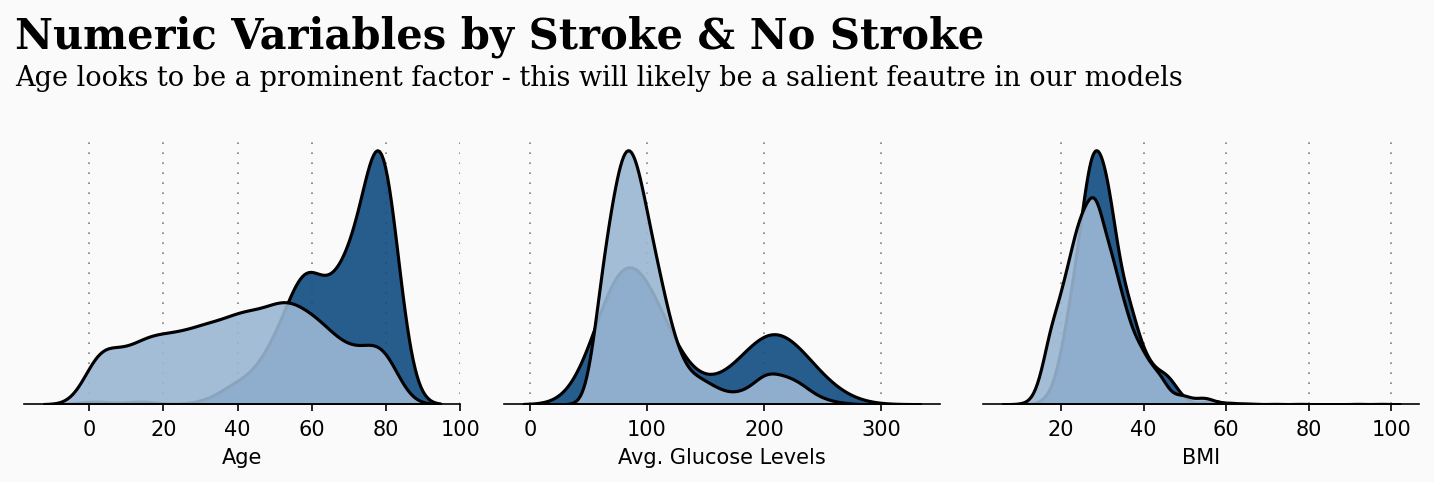

In [75]:
fig = plt.figure(figsize=(12, 12), dpi=150,facecolor=background_color)
gs = fig.add_gridspec(4, 3)
gs.update(wspace=0.1, hspace=0.4)


plot = 0
for row in range(0, 1):
    for col in range(0, 3):
        locals()["ax"+str(plot)] = fig.add_subplot(gs[row, col])
        locals()["ax"+str(plot)].set_facecolor(background_color)
        locals()["ax"+str(plot)].tick_params(axis='y', left=False)
        locals()["ax"+str(plot)].get_yaxis().set_visible(False)
        for s in ["top","right","left"]:
            locals()["ax"+str(plot)].spines[s].set_visible(False)
        plot += 1

plot = 0

s = df[df['stroke'] == 1]
ns = df[df['stroke'] == 0]

for feature in conts:
        sns.kdeplot(s[feature], ax=locals()["ax"+str(plot)], color='#0f4c81', shade=True, linewidth=1.5, ec='black',alpha=0.9, zorder=3, legend=False)
        sns.kdeplot(ns[feature],ax=locals()["ax"+str(plot)], color='#9bb7d4', shade=True, linewidth=1.5, ec='black',alpha=0.9, zorder=3, legend=False)
        locals()["ax"+str(plot)].grid(which='major', axis='x', zorder=0, color='gray', linestyle=':', dashes=(1,5))
        #locals()["ax"+str(plot)].set_xlabel(feature)
        plot += 1

ax0.set_xlabel('Age')
ax1.set_xlabel('Avg. Glucose Levels')
ax2.set_xlabel('BMI')
        
ax0.text(-20, 0.056, 'Numeric Variables by Stroke & No Stroke', fontsize=20, fontweight='bold', fontfamily='serif')
ax0.text(-20, 0.05, 'Age looks to be a prominent factor - this will likely be a salient feautre in our models', 
         fontsize=13, fontweight='light', fontfamily='serif')

plt.show()


# Insight

Based on the above plots, it seems clear that **Age is a big factor** in stroke patients - the older you get the more at risk you are.

Though less obvious, there are also differences in Avg. Glucose Levels and BMI.

Let's explore those variables further...

In [76]:
str_only = df[df['stroke'] == 1]
no_str_only = df[df['stroke'] == 0]

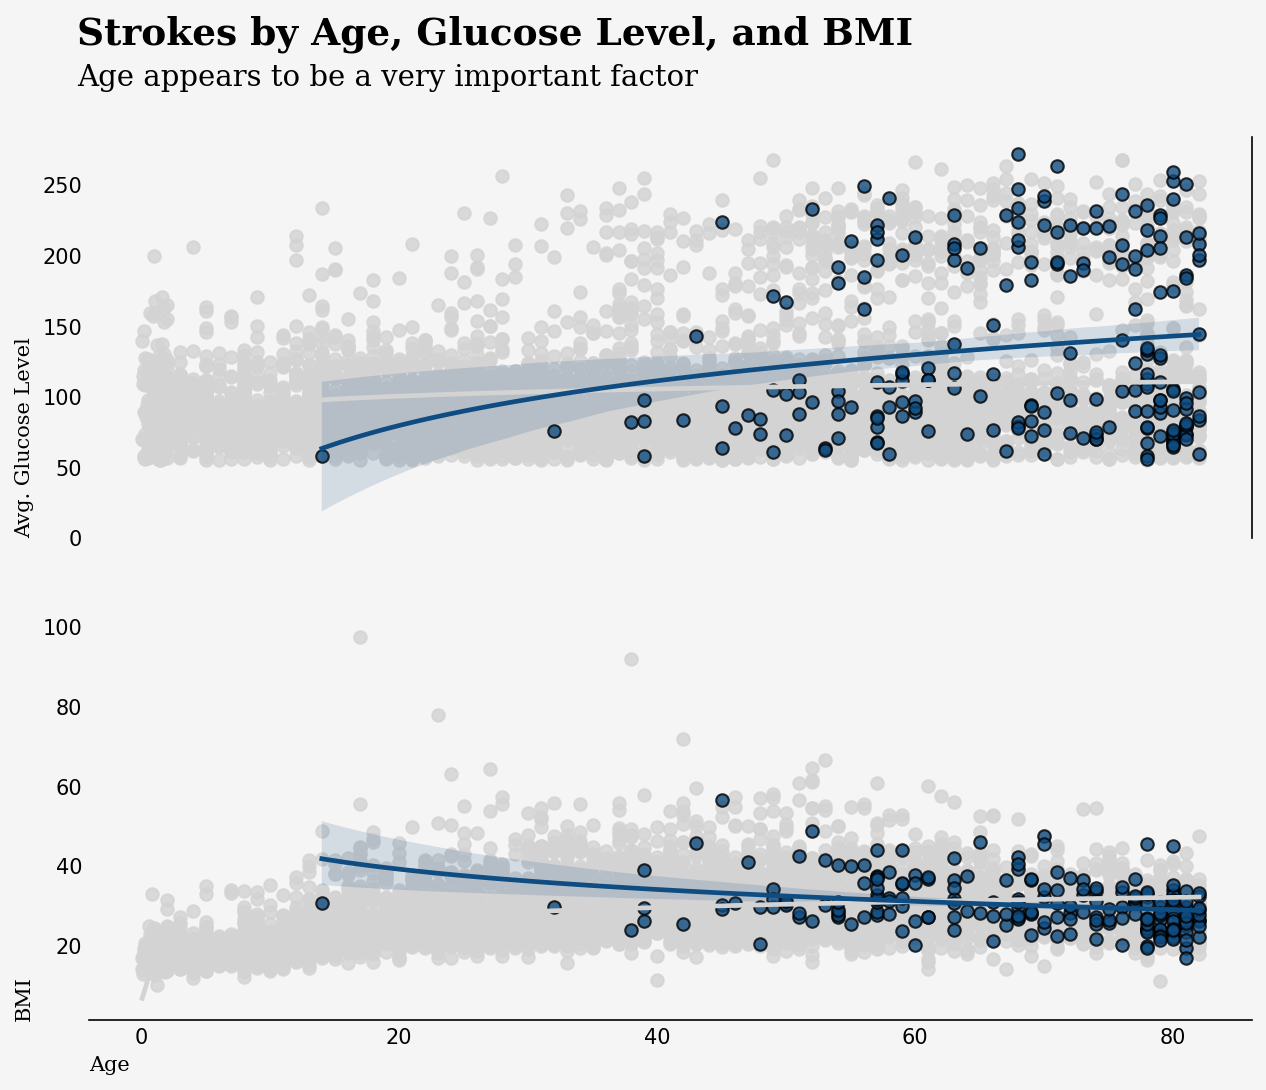

In [77]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Assuming no_str_only and str_only are your dataframes

# Check and handle missing values
no_str_only = no_str_only.dropna(subset=['age', 'avg_glucose_level', 'bmi'])
str_only = str_only.dropna(subset=['age', 'avg_glucose_level', 'bmi'])

# Check and handle data types
no_str_only['age'] = pd.to_numeric(no_str_only['age'], errors='coerce')
str_only['age'] = pd.to_numeric(str_only['age'], errors='coerce')

background_color = '#f6f5f5'

# Setting up figure and axes
fig = plt.figure(figsize=(10, 16), dpi=150, facecolor=background_color)
gs = fig.add_gridspec(4, 2)
gs.update(wspace=0.5, hspace=0.2)
ax0 = fig.add_subplot(gs[0, 0:2])
ax1 = fig.add_subplot(gs[1, 0:2])

ax0.set_facecolor(background_color)
ax1.set_facecolor(background_color)

# Glucose
sns.regplot(x=no_str_only['age'], y=no_str_only['avg_glucose_level'],
            color='lightgray',
            logx=True,
            ax=ax0)

sns.regplot(x=str_only['age'], y=str_only['avg_glucose_level'],
            color='#0f4c81',
            logx=True, scatter_kws={'edgecolors': ['black'],
                                    'linewidth': 1},
            ax=ax0)

ax0.set(ylim=(0, None))
ax0.set_xlabel(" ", fontsize=12, fontfamily='serif')
ax0.set_ylabel("Avg. Glucose Level", fontsize=10, fontfamily='serif', loc='bottom')

ax0.tick_params(axis='x', bottom=False)
ax0.get_xaxis().set_visible(False)

for s in ['top', 'left', 'bottom']:
    ax0.spines[s].set_visible(False)

# BMI
sns.regplot(x=no_str_only['age'], y=no_str_only['bmi'],
            color='lightgray',
            logx=True,
            ax=ax1)

sns.regplot(x=str_only['age'], y=str_only['bmi'],
            color='#0f4c81', scatter_kws={'edgecolors': ['black'],
                                          'linewidth': 1},
            logx=True,
            ax=ax1)

ax1.set_xlabel("Age", fontsize=10, fontfamily='serif', loc='left')
ax1.set_ylabel("BMI", fontsize=10, fontfamily='serif', loc='bottom')

for s in ['top', 'left', 'right']:
    ax1.spines[s].set_visible(False)

ax0.text(-5, 350, 'Strokes by Age, Glucose Level, and BMI', fontsize=18, fontfamily='serif', fontweight='bold')
ax0.text(-5, 320, 'Age appears to be a very important factor', fontsize=14, fontfamily='serif')

ax0.tick_params(axis=u'both', which=u'both', length=0)
ax1.tick_params(axis=u'both', which=u'both', length=0)

plt.show()


As we suspected, Age is a big factor, and also has slight relationships with BMI & Avg. Glucose levels.

We might understand intuitively that **as Age increases, the risk of having a stroke increases too, but can ve visualise this?**

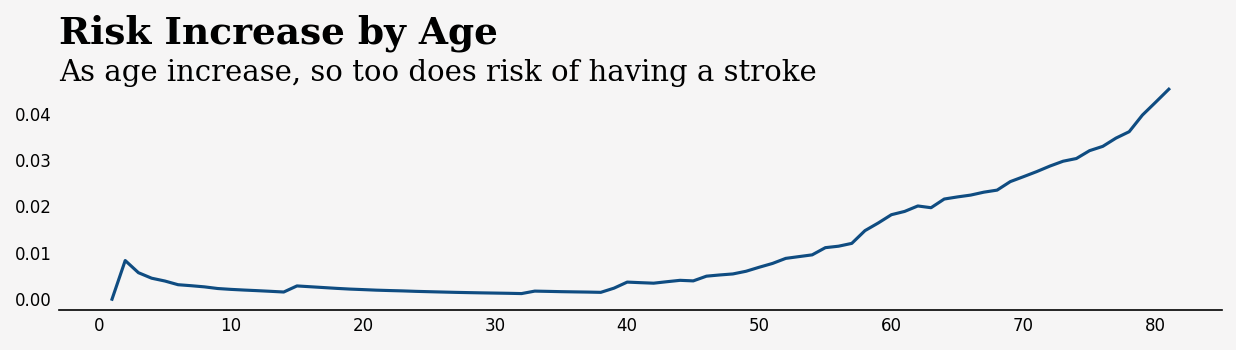

In [78]:
fig = plt.figure(figsize=(10, 5), dpi=150,facecolor=background_color)
gs = fig.add_gridspec(2, 1)
gs.update(wspace=0.11, hspace=0.5)
ax0 = fig.add_subplot(gs[0, 0])
ax0.set_facecolor(background_color)


df['age'] = df['age'].astype(int)

rate = []
for i in range(df['age'].min(), df['age'].max()):
    rate.append(df[df['age'] < i]['stroke'].sum() / len(df[df['age'] < i]['stroke']))

sns.lineplot(data=rate,color='#0f4c81',ax=ax0)

for s in ["top","right","left"]:
    ax0.spines[s].set_visible(False)

ax0.tick_params(axis='both', which='major', labelsize=8)
ax0.tick_params(axis=u'both', which=u'both',length=0)

ax0.text(-3,0.055,'Risk Increase by Age',fontsize=18,fontfamily='serif',fontweight='bold')
ax0.text(-3,0.047,'As age increase, so too does risk of having a stroke',fontsize=14,fontfamily='serif')


plt.show()

This confirms what our intuitions told us. The older you get, the more at risk you get.

However, you may have notices the low risk values on the y-axis. This is because the **dataset is highly imbalanced**.

Only 249 strokes are in our dataset which totals 5000 - around 1 in 20. 

In [79]:
# Drop single 'Other' gender
no_str_only = no_str_only[(no_str_only['gender'] != 'Other')]

# General Overview

We've assessed a few variables so far, and gained some powerful insights. 

I'll now plot several variables in one place, so we can spot interesting trends or features.

I will split the data in to 'Stroke' and 'No-Stroke' so we can see if these two populations differ in any meaningful way.

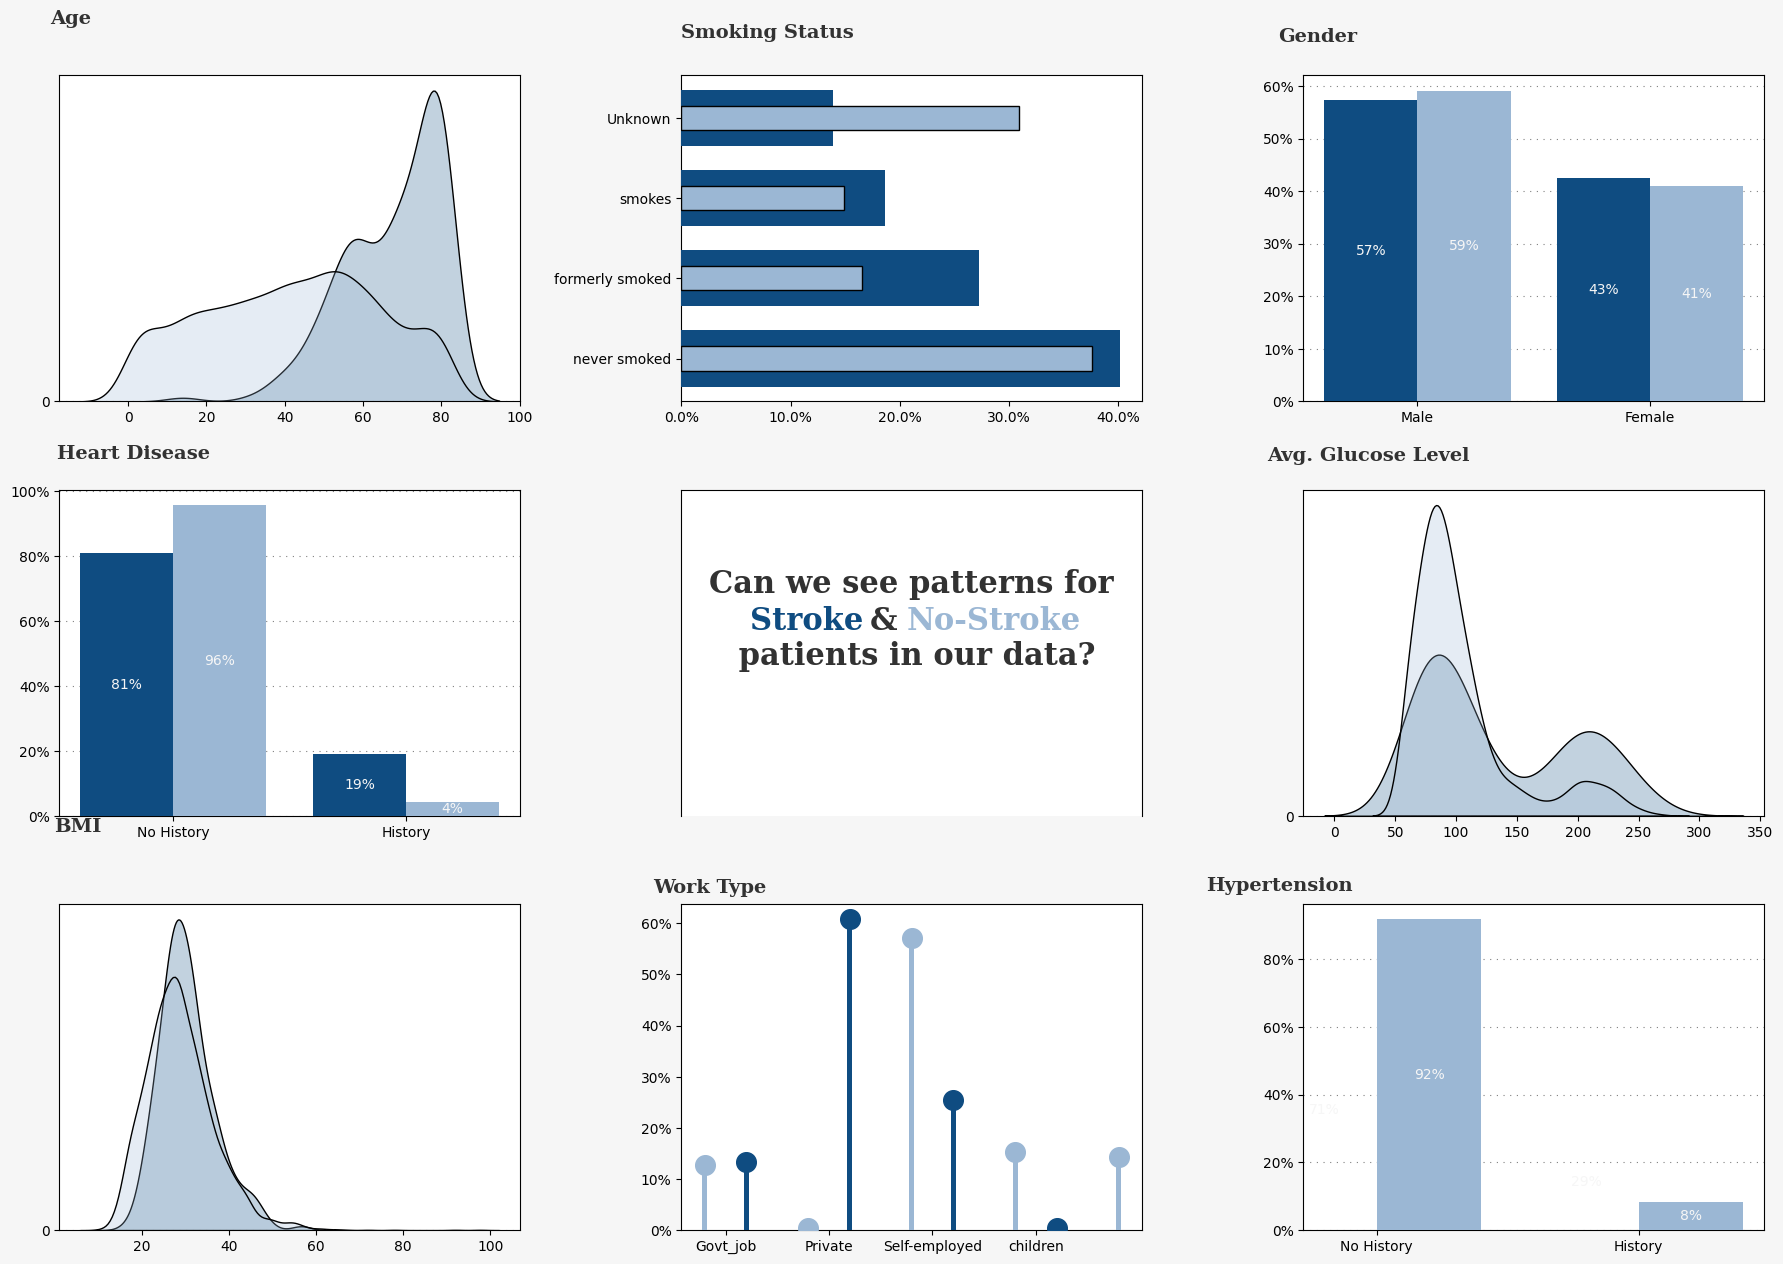

In [80]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.ticker as mtick

# Assuming no_str_only and str_only are your dataframes

background_color = "#f6f6f6"
fig, axs = plt.subplots(3, 3, figsize=(22, 15), gridspec_kw={'wspace': 0.35, 'hspace': 0.27})
fig.patch.set_facecolor(background_color)  # figure background color

# Age
axs[0, 0].grid(color='gray', linestyle=':', axis='y', zorder=0, dashes=(1, 5))
positive_age = str_only["age"].dropna()
negative_age = no_str_only["age"].dropna()
sns.kdeplot(positive_age, ax=axs[0, 0], color="#0f4c81", shade=True, ec='black', label="positive")
sns.kdeplot(negative_age, ax=axs[0, 0], color="#9bb7d4", shade=True, ec='black', label="negative")
axs[0, 0].yaxis.set_major_locator(mtick.MultipleLocator(2))
axs[0, 0].set_ylabel('')
axs[0, 0].set_xlabel('')
axs[0, 0].text(-20, 0.0465, 'Age', fontsize=14, fontweight='bold', fontfamily='serif', color="#323232")

# Smoking
positive_smoking = str_only["smoking_status"].value_counts()
positive_smoking_percentage = (positive_smoking / positive_smoking.sum()) * 100
negative_smoking = no_str_only["smoking_status"].value_counts()
negative_smoking_percentage = (negative_smoking / negative_smoking.sum()) * 100

axs[0, 1].text(0, 4, 'Smoking Status', fontsize=14, fontweight='bold', fontfamily='serif', color="#323232")
axs[0, 1].barh(positive_smoking.index, positive_smoking_percentage, color="#0f4c81", zorder=3, height=0.7)
axs[0, 1].barh(negative_smoking.index, negative_smoking_percentage, color="#9bb7d4", zorder=3, ec='black', height=0.3)
axs[0, 1].xaxis.set_major_formatter(mtick.PercentFormatter())
axs[0, 1].xaxis.set_major_locator(mtick.MultipleLocator(10))

# Gender
positive_gender = str_only["gender"].value_counts()
positive_gender_percentage = (positive_gender / positive_gender.sum()) * 100
negative_gender = no_str_only["gender"].value_counts()
negative_gender_percentage = (negative_gender / negative_gender.sum()) * 100

x_gender = np.arange(len(positive_gender))
axs[0, 2].text(-0.4, 68.5, 'Gender', fontsize=14, fontweight='bold', fontfamily='serif', color="#323232")
axs[0, 2].grid(color='gray', linestyle=':', axis='y', zorder=0, dashes=(1, 5))
axs[0, 2].bar(x_gender, height=positive_gender_percentage, zorder=3, color="#0f4c81", width=0.4)
axs[0, 2].bar(x_gender + 0.4, height=negative_gender_percentage, zorder=3, color="#9bb7d4", width=0.4)
axs[0, 2].set_xticks(x_gender + 0.4 / 2)
axs[0, 2].set_xticklabels(['Male', 'Female'])
axs[0, 2].yaxis.set_major_formatter(mtick.PercentFormatter())
axs[0, 2].yaxis.set_major_locator(mtick.MultipleLocator(10))
for i, j in zip([0, 1], positive_gender_percentage):
    axs[0, 2].annotate(f'{j:0.0f}%', xy=(i, j / 2), color='#f6f6f6', horizontalalignment='center',
                       verticalalignment='center')
for i, j in zip([0, 1], negative_gender_percentage):
    axs[0, 2].annotate(f'{j:0.0f}%', xy=(i + 0.4, j / 2), color='#f6f6f6', horizontalalignment='center',
                       verticalalignment='center')

# Heart Disease
positive_heart_disease = str_only["heart_disease"].value_counts()
positive_heart_disease_percentage = (positive_heart_disease / positive_heart_disease.sum()) * 100
negative_heart_disease = no_str_only["heart_disease"].value_counts()
negative_heart_disease_percentage = (negative_heart_disease / negative_heart_disease.sum()) * 100

x_heart_disease = np.arange(len(positive_heart_disease))
axs[1, 0].text(-0.3, 110, 'Heart Disease', fontsize=14, fontweight='bold', fontfamily='serif', color="#323232")
axs[1, 0].grid(color='gray', linestyle=':', axis='y', zorder=0, dashes=(1, 5))
axs[1, 0].bar(x_heart_disease, height=positive_heart_disease_percentage, zorder=3, color="#0f4c81", width=0.4)
axs[1, 0].bar(x_heart_disease + 0.4, height=negative_heart_disease_percentage, zorder=3, color="#9bb7d4", width=0.4)
axs[1, 0].set_xticks(x_heart_disease + 0.4 / 2)
axs[1, 0].set_xticklabels(['No History', 'History'])
axs[1, 0].yaxis.set_major_formatter(mtick.PercentFormatter())
axs[1, 0].yaxis.set_major_locator(mtick.MultipleLocator(20))
for i, j in zip([0, 1], positive_heart_disease_percentage):
    axs[1, 0].annotate(f'{j:0.0f}%', xy=(i, j / 2), color='#f6f6f6', horizontalalignment='center',
                       verticalalignment='center')
for i, j in zip([0, 1], negative_heart_disease_percentage):
    axs[1, 0].annotate(f'{j:0.0f}%', xy=(i + 0.4, j / 2), color='#f6f6f6', horizontalalignment='center',
                       verticalalignment='center')

# Title
axs[1, 1].spines["bottom"].set_visible(False)
axs[1, 1].tick_params(left=False, bottom=False)
axs[1, 1].set_xticklabels([])
axs[1, 1].set_yticklabels([])
axs[1, 1].text(0.5, 0.6, 'Can we see patterns for\n\n patients in our data?', horizontalalignment='center',
               verticalalignment='center',
               fontsize=22, fontweight='bold', fontfamily='serif', color="#323232")
axs[1, 1].text(0.15, 0.57, "Stroke", fontweight="bold", fontfamily='serif', fontsize=22, color='#0f4c81')
axs[1, 1].text(0.41, 0.57, "&", fontweight="bold", fontfamily='serif', fontsize=22, color='#323232')
axs[1, 1].text(0.49, 0.57, "No-Stroke", fontweight="bold", fontfamily='serif', fontsize=22, color='#9bb7d4')

# Avg. Glucose Level
axs[1, 2].grid(color='gray', linestyle=':', axis='y', zorder=0, dashes=(1, 5))
positive_glucose = str_only["avg_glucose_level"].dropna()
negative_glucose = no_str_only["avg_glucose_level"].dropna()
sns.kdeplot(positive_glucose, ax=axs[1, 2], color="#0f4c81", ec='black', shade=True, label="positive")
sns.kdeplot(negative_glucose, ax=axs[1, 2], color="#9bb7d4", ec='black', shade=True, label="negative")
axs[1, 2].text(-55, 0.01855, 'Avg. Glucose Level', fontsize=14, fontweight='bold', fontfamily='serif',
               color="#323232")
axs[1, 2].yaxis.set_major_locator(mtick.MultipleLocator(2))
axs[1, 2].set_ylabel('')
axs[1, 2].set_xlabel('')

# BMI
axs[2, 0].grid(color='gray', linestyle=':', axis='y', zorder=0, dashes=(1, 5))
positive_bmi = str_only["bmi"].dropna()
negative_bmi = no_str_only["bmi"].dropna()
sns.kdeplot(positive_bmi, ax=axs[2, 0], color="#0f4c81", ec='black', shade=True, label="positive")
sns.kdeplot(negative_bmi, ax=axs[2, 0], color="#9bb7d4", ec='black', shade=True, label="negative")
axs[2, 0].text(-0.06, 0.09, 'BMI', fontsize=14, fontweight='bold', fontfamily='serif', color="#323232")
axs[2, 0].yaxis.set_major_locator(mtick.MultipleLocator(2))
axs[2, 0].set_ylabel('')
axs[2, 0].set_xlabel('')

# Work Type
positive_work_type = str_only["work_type"].value_counts().sort_index()
positive_work_type_percentage = (positive_work_type / positive_work_type.sum()) * 100
negative_work_type = no_str_only["work_type"].value_counts().sort_index()
negative_work_type_percentage = (negative_work_type / negative_work_type.sum()) * 100

axs[2, 1].bar(negative_work_type.index, height=negative_work_type_percentage, zorder=3, color="#9bb7d4", width=0.05)
axs[2, 1].scatter(negative_work_type.index, negative_work_type_percentage, zorder=3, s=200, color="#9bb7d4")
axs[2, 1].bar(np.arange(len(positive_work_type.index)) + 0.4, height=positive_work_type_percentage, zorder=3,
              color="#0f4c81", width=0.05)
axs[2, 1].scatter(np.arange(len(positive_work_type.index)) + 0.4, positive_work_type_percentage, zorder=3, s=200,
                  color="#0f4c81")
axs[2, 1].yaxis.set_major_formatter(mtick.PercentFormatter())
axs[2, 1].yaxis.set_major_locator(mtick.MultipleLocator(10))
axs[2, 1].set_xticks(np.arange(len(positive_work_type.index)) + 0.4 / 2)
axs[2, 1].set_xticklabels(list(positive_work_type.index), rotation=0)
axs[2, 1].text(-0.5, 66, 'Work Type', fontsize=14, fontweight='bold', fontfamily='serif', color="#323232")

# Hypertension
positive_hypertension = str_only["hypertension"].value_counts()
positive_hypertension_percentage = (positive_hypertension / positive_hypertension.sum()) * 100
negative_hypertension = no_str_only["hypertension"].value_counts()
negative_hypertension_percentage = (negative_hypertension / negative_hypertension.sum()) * 100

x_hypertension = np.arange(len(positive_hypertension))
axs[2, 2].text(-0.45, 100, 'Hypertension', fontsize=14, fontweight='bold', fontfamily='serif', color="#323232")
axs[2, 2].grid(color='gray', linestyle=':', axis='y', zorder=0, dashes=(1, 5))
axs[2, 2].bar(x_hypertension, height=positive_hypertension_percentage, zorder=3, color="#0f4c81", width=0)
axs[2, 2].bar(x_hypertension + 0.4, height=negative_hypertension_percentage, zorder=3, color="#9bb7d4", width=0.4)
axs[2, 2].set_xticks(x_hypertension + 0.4 / 2)
axs[2, 2].set_xticklabels(['No History', 'History'])
axs[2, 2].yaxis.set_major_formatter(mtick.PercentFormatter())
axs[2, 2].yaxis.set_major_locator(mtick.MultipleLocator(20))

# Corrected loop for percentages
for i, j in zip(x_hypertension, positive_hypertension_percentage):
    axs[2, 2].annotate(f'{j:0.0f}%', xy=(i, j/2), color='#f6f6f6', horizontalalignment='center', verticalalignment='center')
for i, j in zip(x_hypertension, negative_hypertension_percentage):
    axs[2, 2].annotate(f'{j:0.0f}%', xy=(i + 0.4, j/2), color='#f6f6f6', horizontalalignment='center', verticalalignment='center')

# tidy up

for s in ["top","right","left"]:
    for i in range(0,9):
        locals()["ax"+str(i)].spines[s].set_visible(False)
        
for i in range(0,9):
        locals()["ax"+str(i)].set_facecolor(background_color)
        locals()["ax"+str(i)].tick_params(axis=u'both', which=u'both',length=0)
        locals()["ax"+str(i)].set_facecolor(background_color) 

        
plt.show()

# Insights

The plots above are quite enlightening.

As discussed earlier, we again note the importance of Age, amongst other things.

### The 'bmi' feature contains missing or null values.

In [81]:
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

### We substituted the missing values in the 'bmi' column with the mean of that specific column (0).

In [82]:
df.bmi.replace(to_replace=np.nan, value=df.bmi.mean(0), inplace=True)

### Upon inspection, it's evident that our column does not contain any null values.

In [83]:
df.isnull().sum()

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

### Following the verification of the absence of null values in the "bmi" column, we proceed to generate descriptive statistics for the entire DataFrame.

In [84]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000
mean,36517.829354,43.215264,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.633866,0.296607,0.226063,45.283560,7.698018,0.215320
min,67.000000,0.000000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.800000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.400000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,32.800000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


### To prepare the data for our model, we perform a conversion of all string values in the columns: gender, ever_married, work_type, Residence_type, and smoking_status, into their corresponding numerical representations, typically floats.

In [85]:
df["gender"].replace({'Male': 0, 
                        'Female': 1,
                       'Other': 2,}, inplace=True)
df["ever_married"].replace({'Yes': 1,'No': 0,}, inplace=True)
df["work_type"].replace({'Private': 0,
                           'Self-employed': 1,
                          'Govt_job': 2,
                          'children': 3,
                          'Never_worked': 4,}, inplace=True)
df["Residence_type"].replace({'Urban': 1,
                                'Rural': 0,}, inplace=True)
df["smoking_status"].replace({'formerly smoked': 0,
                                'never smoked': 1,
                                'smokes': 2,
                                'Unknown': 3,}, inplace=True)

### Upon examination, it becomes evident that all the strings in the aforementioned columns have successfully undergone conversion to float data type.

In [86]:
df.head

<bound method NDFrame.head of          id  gender  age  hypertension  heart_disease  ever_married  \
0      9046       0   67             0              1             1   
1     51676       1   61             0              0             1   
2     31112       0   80             0              1             1   
3     60182       1   49             0              0             1   
4      1665       1   79             1              0             1   
...     ...     ...  ...           ...            ...           ...   
5105  18234       1   80             1              0             1   
5106  44873       1   81             0              0             1   
5107  19723       1   35             0              0             1   
5108  37544       0   51             0              0             1   
5109  44679       1   44             0              0             1   

      work_type  Residence_type  avg_glucose_level        bmi  smoking_status  \
0             0               1     

### Upon completing the preceding steps, we proceed to examine the correlation among the numerical columns within our dataset.

In [87]:
df.corr()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
id,1.000000,-0.001406,0.003503,0.003550,-0.001296,0.013690,-0.018030,-0.001403,0.001092,0.002999,-0.018551,0.006388
gender,-0.001406,1.000000,0.027404,-0.021390,-0.085749,0.029366,-0.066212,0.005529,-0.054213,0.025110,-0.039693,-0.009200
age,0.003503,0.027404,1.000000,0.276303,0.263668,0.679181,-0.413852,0.014169,0.238060,0.326271,-0.376142,0.245128
hypertension,0.003550,-0.021390,0.276303,1.000000,0.108306,0.164243,-0.075097,-0.007913,0.174474,0.160189,-0.129012,0.127904
heart_disease,-0.001296,-0.085749,0.263668,0.108306,1.000000,0.114644,-0.058263,0.003092,0.161857,0.038899,-0.064671,0.134914
ever_married,0.013690,0.029366,0.679181,0.164243,0.114644,1.000000,-0.375944,0.006261,0.155068,0.335705,-0.303694,0.108340
work_type,-0.018030,-0.066212,-0.413852,-0.075097,-0.058263,-0.375944,1.000000,0.014573,-0.068135,-0.341973,0.307774,-0.058224
Residence_type,-0.001403,0.005529,0.014169,-0.007913,0.003092,0.006261,0.014573,1.000000,-0.004946,-0.000120,0.004656,0.015458
avg_glucose_level,0.001092,-0.054213,0.238060,0.174474,0.161857,0.155068,-0.068135,-0.004946,1.000000,0.168751,-0.097732,0.131945
bmi,0.002999,0.025110,0.326271,0.160189,0.038899,0.335705,-0.341973,-0.000120,0.168751,1.000000,-0.230553,0.038947


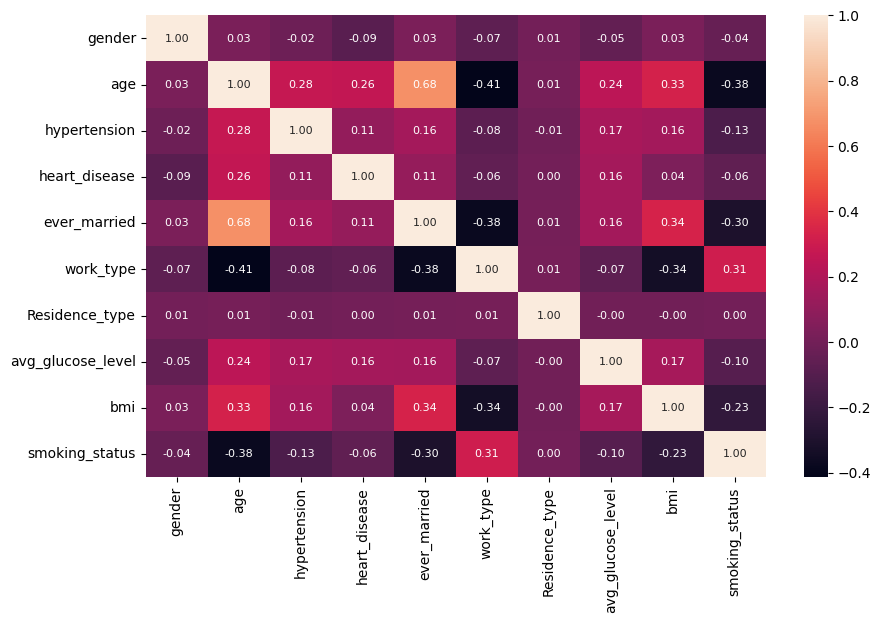

In [88]:
plt.figure(figsize = (10, 6))
corr_matrix = df[['gender', 'age','hypertension', 'heart_disease', 'ever_married', 'work_type', 
                     'Residence_type', 'avg_glucose_level', 'bmi','smoking_status']].corr()
sns.heatmap(corr_matrix, annot=True, fmt = '.2f', annot_kws = {'size': 8}, vmax= 1)
plt.show()

### At this point, we can assert that our data is prepared for the modeling phase of our stroke prediction analysis.

# Model Implementation

In [89]:
# Train-test split on the original data
X = df.drop(columns='stroke')
y = df.stroke
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=23)

# Apply SMOTE only to the training data
sm = SMOTE()
X_res, y_res = sm.fit_resample(x_train,y_train)

# Check the shapes and counts after oversampling
print("Before OverSampling, counts of label '1': {}".format(sum(y==1)))
print("Before OverSampling, counts of label '0': {} \n".format(sum(y==0)))

print('After OverSampling, the shape of train_X: {}'.format(X_res.shape))
print('After OverSampling, the shape of train_y: {} \n'.format(y_res.shape))

print("After OverSampling, counts of label '1': {}".format(sum(y_res==1)))
print("After OverSampling, counts of label '0': {}".format(sum(y_res==0)))

Before OverSampling, counts of label '1': 249
Before OverSampling, counts of label '0': 4861 

After OverSampling, the shape of train_X: (7788, 11)
After OverSampling, the shape of train_y: (7788,) 

After OverSampling, counts of label '1': 3894
After OverSampling, counts of label '0': 3894


### Support vector machines (SVMs)
SVMs are a type of supervised learning algorithm used for classification and regression tasks. In the context of classification, SVMs aim to find a hyperplane that best separates the data into different classes. 


In [100]:
# Train the SVM model without SMOTE
model_svm = SVC(kernel = 'linear', random_state = 0)
model_svm_smote = SVC(kernel = 'linear', random_state = 0)
model_svm.fit(x_train, y_train)
model_svm_smote.fit(X_res, y_res)

SVC(kernel='linear', random_state=0)

In [101]:
# Makeing predictions on the test set
y_pred = model_svm.predict(x_test)
y_pred_smote = model_svm_smote.predict(x_test)

### SVM Evaluation

In [102]:
# Calculate accuracy
accuracy_svm = accuracy_score(y_test, y_pred)
accuracy_svm_smote = accuracy_score(y_test, y_pred_smote)
print("SVM Accuracy without SMOTE:" , accuracy_svm)
print("SVM Accuracy with SMOTE:" , accuracy_svm_smote)

SVM Accuracy without SMOTE: 0.9403131115459883
SVM Accuracy with SMOTE: 0.7181996086105675


The overall accuracy of the SVM model without SMOTE is 94% and with SMOTE is 71%, suggesting that it performs reasonably well on the test set. The significant drop in accuracy when using SMOTE may indicate that the original dataset had imbalanced class distribution, and the model might be overfitting

In [103]:
classification_rep_svm = classification_report(y_test, y_pred)
print("Report without SMOTE:")
print(classification_rep_svm)
print('***********************************************')
classification_svm_smote = classification_report(y_test, y_pred_smote)
print("Report with SMOTE:")
print(classification_svm_smote)

Report without SMOTE:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       967
           1       0.20      0.04      0.06        55

    accuracy                           0.94      1022
   macro avg       0.57      0.51      0.52      1022
weighted avg       0.91      0.94      0.92      1022

***********************************************
Report with SMOTE:
              precision    recall  f1-score   support

           0       0.98      0.72      0.83       967
           1       0.13      0.75      0.22        55

    accuracy                           0.72      1022
   macro avg       0.56      0.73      0.52      1022
weighted avg       0.93      0.72      0.80      1022



Without SMOTE, the model achieved 94% accuracy, with high precision and recall for the majority class (0) but lower performance for the minority class 
With SMOTE, the model's accuracy decreased to 72%, but there was an improvement in precision and recall for the minority class, balancing performance across classes.

### Decision Tree Classification

In [108]:
DT_Model = DecisionTreeClassifier()
DT_Model_smote = DecisionTreeClassifier()
DT_Model.fit(x_train, y_train)
DT_Model_smote.fit(X_res, y_res)

DecisionTreeClassifier()

The overall accuracy of the Decision Tree model is 83%, suggesting that it performs better that two other models on the test set.

In [109]:
# Makeing predictions on the test set
y_pred = DT_Model.predict(x_test)
y_pred_smote = DT_Model_smote.predict(x_test)

### Decision Tree Evaluation

In [110]:
# Calculate accuracy
DT_acc = accuracy_score(y_test, y_pred)
DT_acc_smote = accuracy_score(y_test, y_pred_smote)
print("Decision Tree Accuracy without SMOTE:" , DT_acc)
print("Decision Tree Accuracy with SMOTE:" , DT_acc_smote)

Decision Tree Accuracy without SMOTE: 0.898238747553816
Decision Tree Accuracy with SMOTE: 0.8522504892367906


The overall accuracy of the Decision Tree model without SMOTE is 89% and with SMOTE is 85%, suggesting that it performs reasonably well on the test set. This model performs better than SVM and Logistic Regression

In [111]:
DT_rep = classification_report(y_test, y_pred)
print("Report without SMOTE:")
print(DT_rep)
print('***********************************************')
DT_rep_smote = classification_report(y_test, y_pred_smote)
print("Report with SMOTE:")
print(DT_rep_smote)

Report without SMOTE:
              precision    recall  f1-score   support

           0       0.95      0.94      0.95       967
           1       0.13      0.16      0.15        55

    accuracy                           0.90      1022
   macro avg       0.54      0.55      0.55      1022
weighted avg       0.91      0.90      0.90      1022

***********************************************
Report with SMOTE:
              precision    recall  f1-score   support

           0       0.96      0.88      0.92       967
           1       0.14      0.33      0.19        55

    accuracy                           0.85      1022
   macro avg       0.55      0.60      0.56      1022
weighted avg       0.91      0.85      0.88      1022



Without SMOTE, the decision tree model achieved 90% accuracy, exhibiting balanced precision and recall for class 0, but lower performance for class 1 with a F1-score of 0.15.
With SMOTE, the accuracy decreased to 85%, and although the recall for class 1 improved, the overall F1-score remained low at 0.19, indicating challenges in predicting the minority class.

### Logistic Regression

Logistic regression is a process of modeling the probability of a discrete outcome given an input variable. The most common logistic regression models a binary outcome.

In [112]:
# Train the Logistic Regression model
Log_Model = LogisticRegression()
Log_Model_smote = LogisticRegression()
Log_Model.fit(x_train, y_train)
Log_Model_smote.fit(X_res, y_res)

LogisticRegression()

In [114]:
# Makeing predictions on the test set
y_pred = Log_Model.predict(x_test)
y_pred_smote = Log_Model_smote.predict(x_test)

### Logistic Regression Evaluation
Logistic Regression is a statistical method used for binary classification problems, where the outcome variable is categorical and has two classes. Logistic regression is used for classification. The algorithm has two output [0, 1], 1 indicates that the patient is at risk of heart stroke and 0 indicates that patient is not at risk.

In [115]:
# Calculate accuracy
Log_acc = accuracy_score(y_test, y_pred)
Log_acc_smote = accuracy_score(y_test, y_pred_smote)
print("Decision Tree Accuracy without SMOTE:" , Log_acc)
print("Decision Tree Accuracy with SMOTE:" , Log_acc_smote)

Decision Tree Accuracy without SMOTE: 0.9461839530332681
Decision Tree Accuracy with SMOTE: 0.726027397260274


The overall accuracy of the SVM model without SMOTE is 94% and with SMOTE is 72%, suggesting that it performs reasonably well on the test set. The significant drop in accuracy when using SMOTE may indicate that the original dataset had imbalanced class distribution, and the model might be overfitting

In [116]:
Log_rep = classification_report(y_test, y_pred)
print("Report without SMOTE:")
print(Log_rep)
print('***********************************************')
Log_rep_smote = classification_report(y_test, y_pred_smote)
print("Report with SMOTE:")
print(Log_rep_smote)

Report without SMOTE:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       967
           1       0.00      0.00      0.00        55

    accuracy                           0.95      1022
   macro avg       0.47      0.50      0.49      1022
weighted avg       0.90      0.95      0.92      1022

***********************************************
Report with SMOTE:
              precision    recall  f1-score   support

           0       0.97      0.73      0.83       967
           1       0.12      0.65      0.20        55

    accuracy                           0.73      1022
   macro avg       0.55      0.69      0.52      1022
weighted avg       0.93      0.73      0.80      1022



Without SMOTE, the model achieved 95% accuracy, with excellent precision and recall for the majority class (0) but poor performance for the minority class (1) due to a low F1-score of 0.00.
With SMOTE, the accuracy dropped to 73%, and while there was an improvement in recall for the minority class, the overall F1-score remained low at 0.20, indicating challenges in correctly identifying instances of class 1.

# THANK YOU AND HAPPY NEW YEAR!

From: Riman, Chiamaka, Naeimeh, Malik